In [1]:
import json
# Create histogram of plaque areas
from skimage.measure import label, regionprops
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
from msi_visual.supervised.annotations import get_img, get_visualization, get_dataset

paths = [(r"E:\MSImaging-data\_msi_visual\Extractions\NRL4485-s2\20_bins\0.npy", 1),
        (r"E:\MSImaging-data\_msi_visual\Extractions\NRL4485-s2\20_bins\2.npy", 0),
        (r"E:\MSImaging-data\_msi_visual\Extractions\NRL4485-s2\20_bins\1.npy", 2),
        (r"E:\MSImaging-data\_msi_visual\Extractions\NRL4485-s2\20_bins\3.npy", 3)]
X, all_y, all_label_encoder = get_dataset(r"../scripts/NRL4485-s2_reannotation_23-12-24_PAHJ.json", paths, subsample=2)

using normalization <function total_ion_count at 0x0000019D8DF6ECA0>
using normalization <function total_ion_count at 0x0000019D8DF6ECA0>
using normalization <function total_ion_count at 0x0000019D8DF6ECA0>
using normalization <function total_ion_count at 0x0000019D8DF6ECA0>


c:\Users\PahnkeLab\miniconda3\envs\maldi\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



(108148,) (108148,)


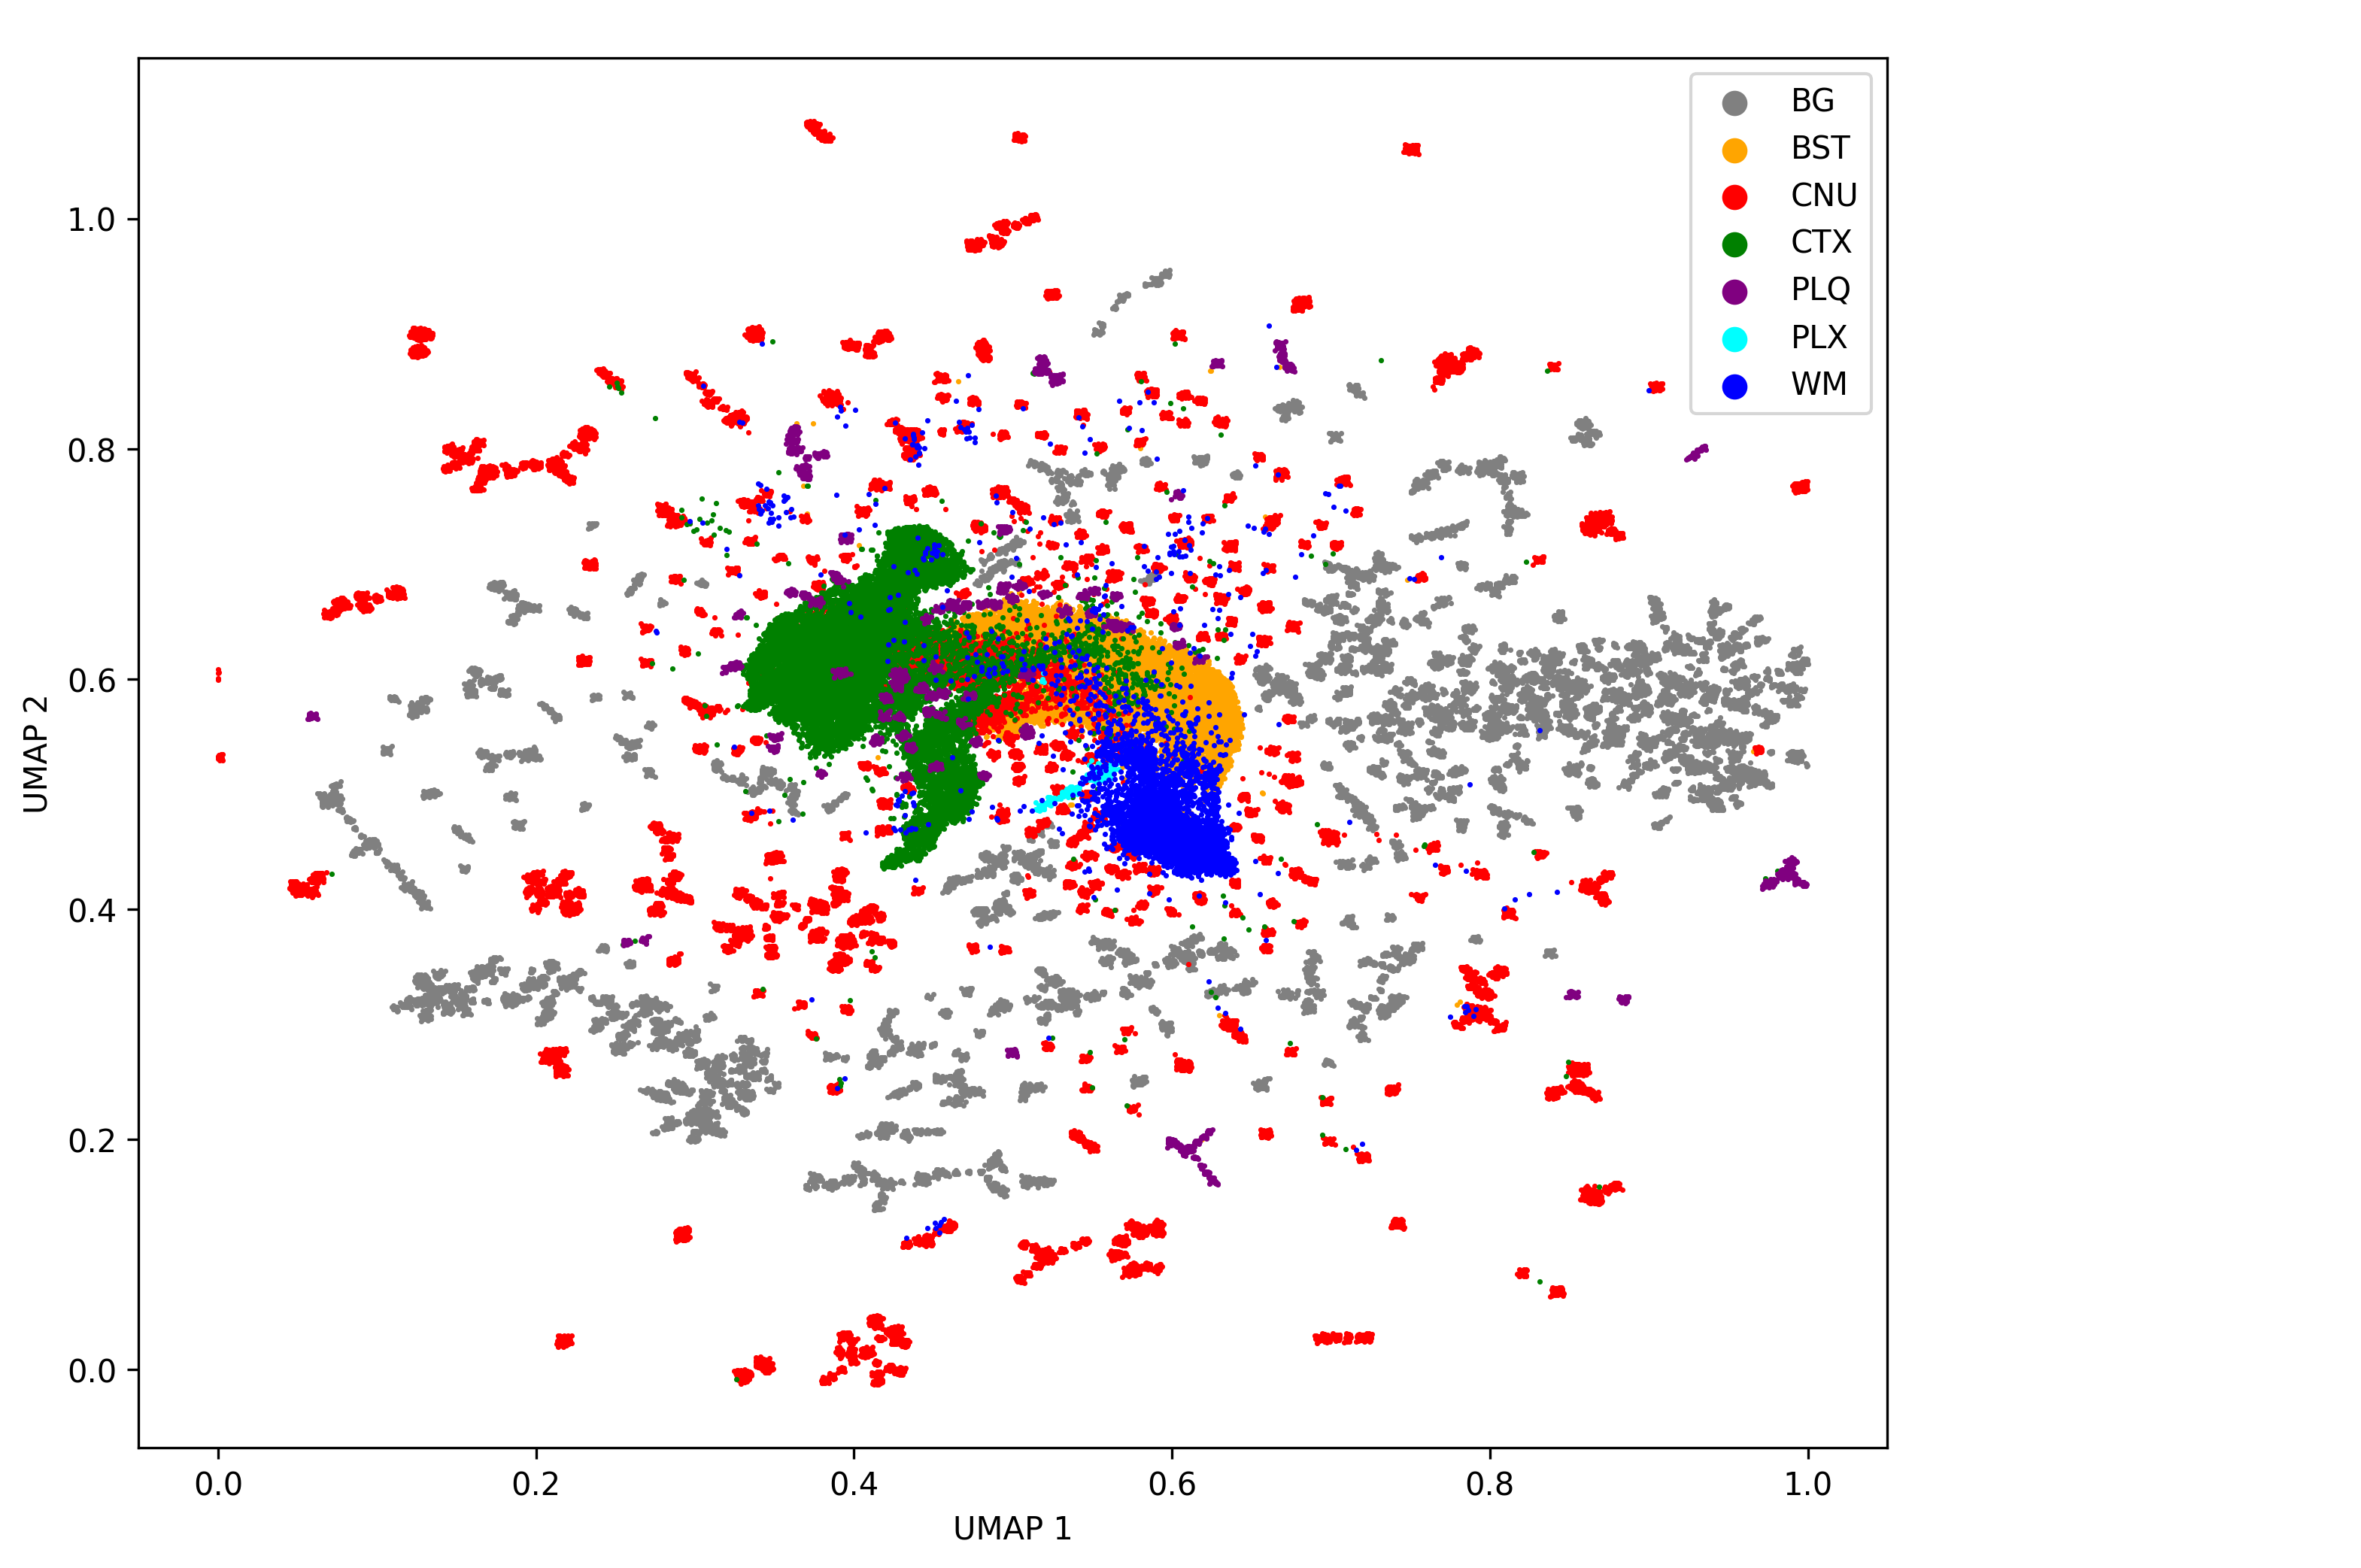

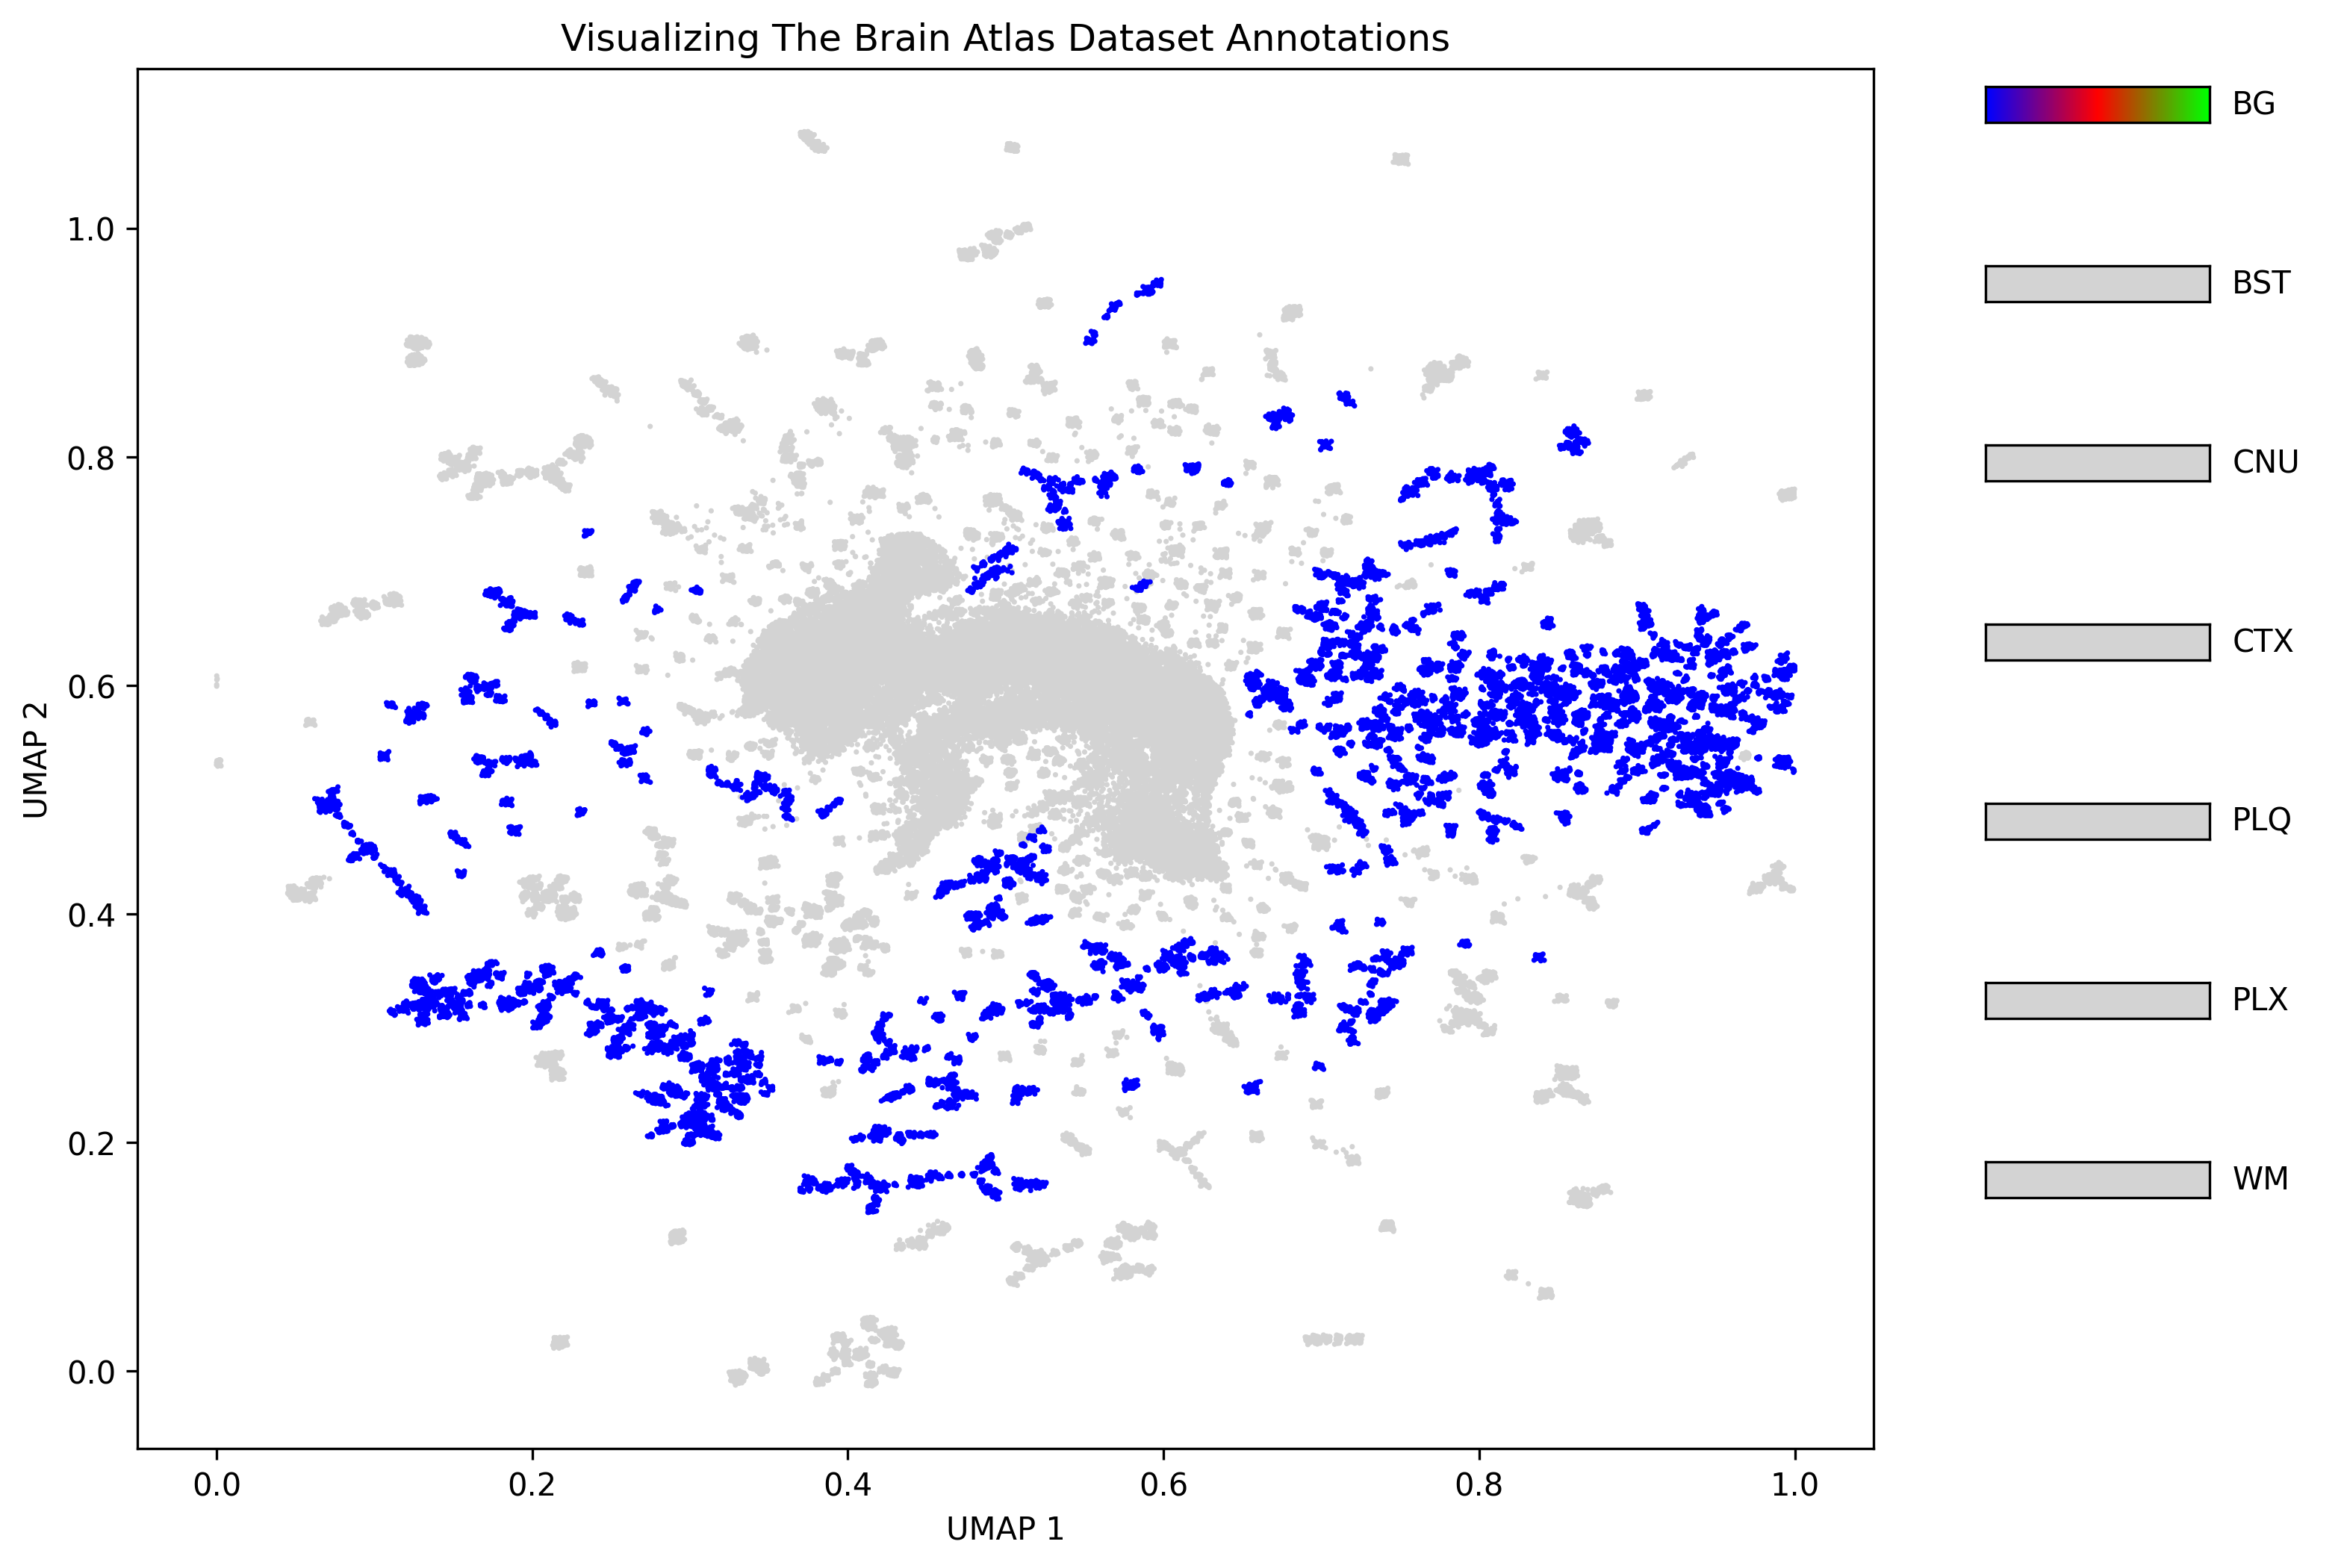

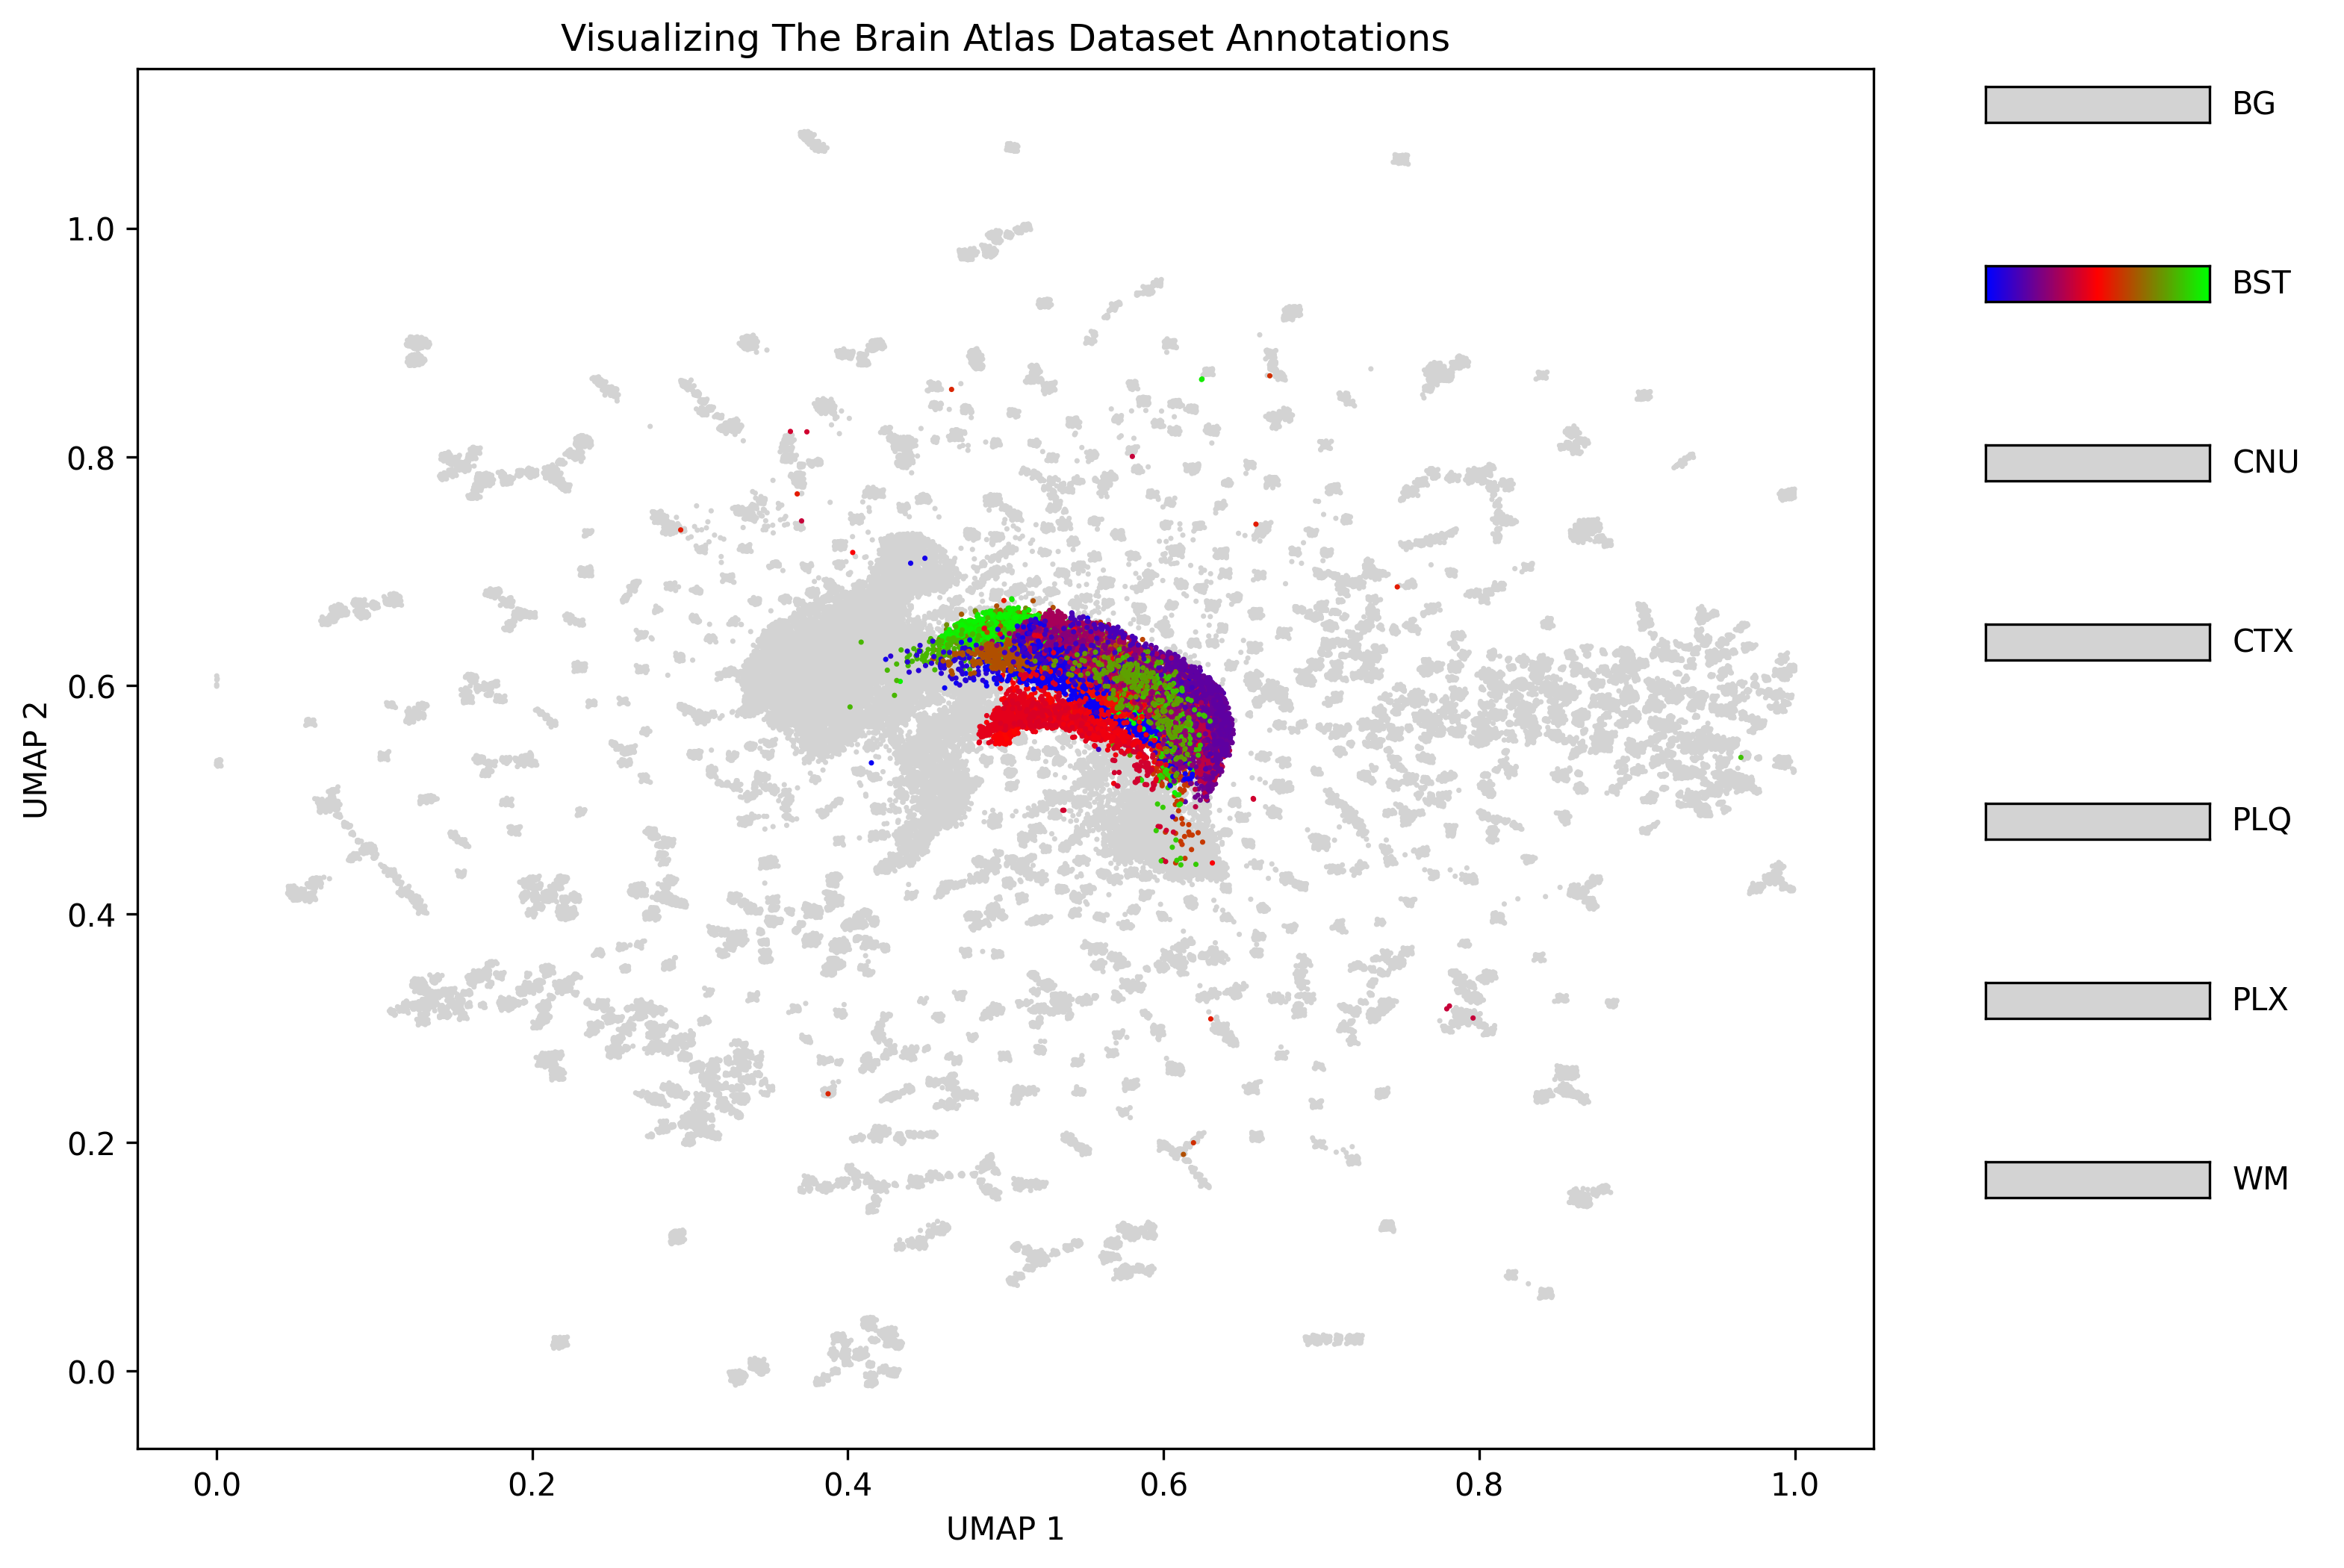

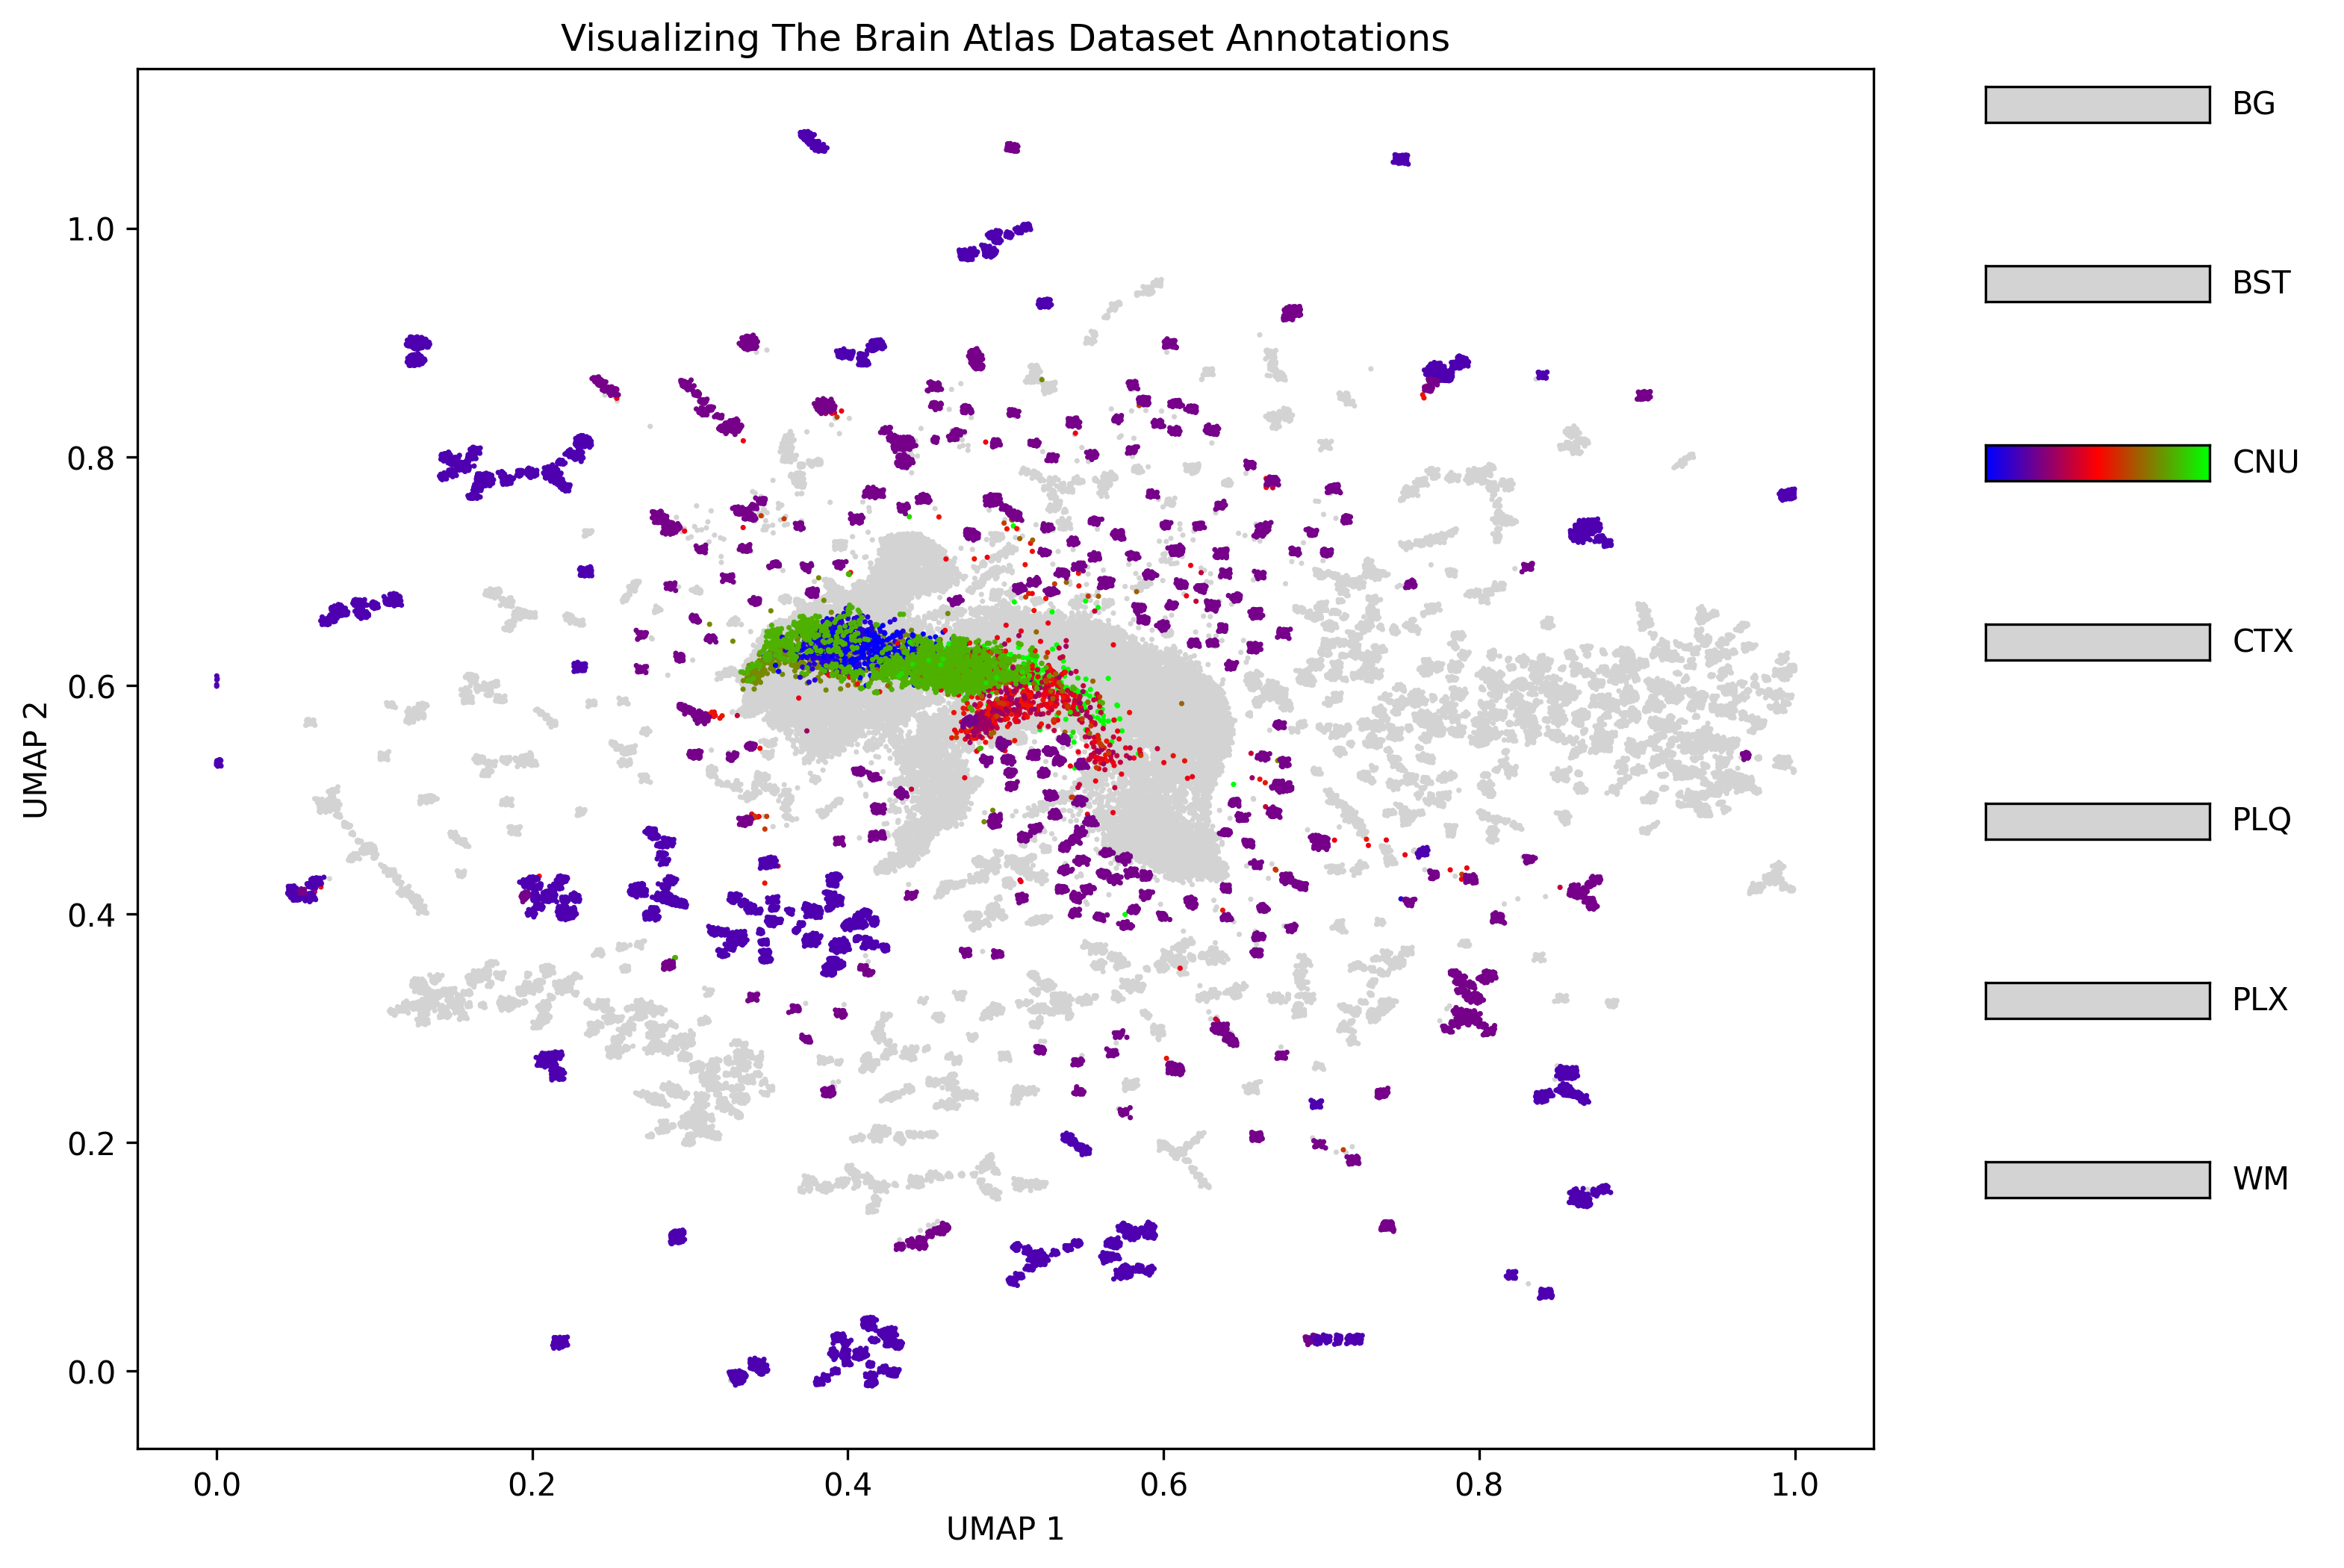

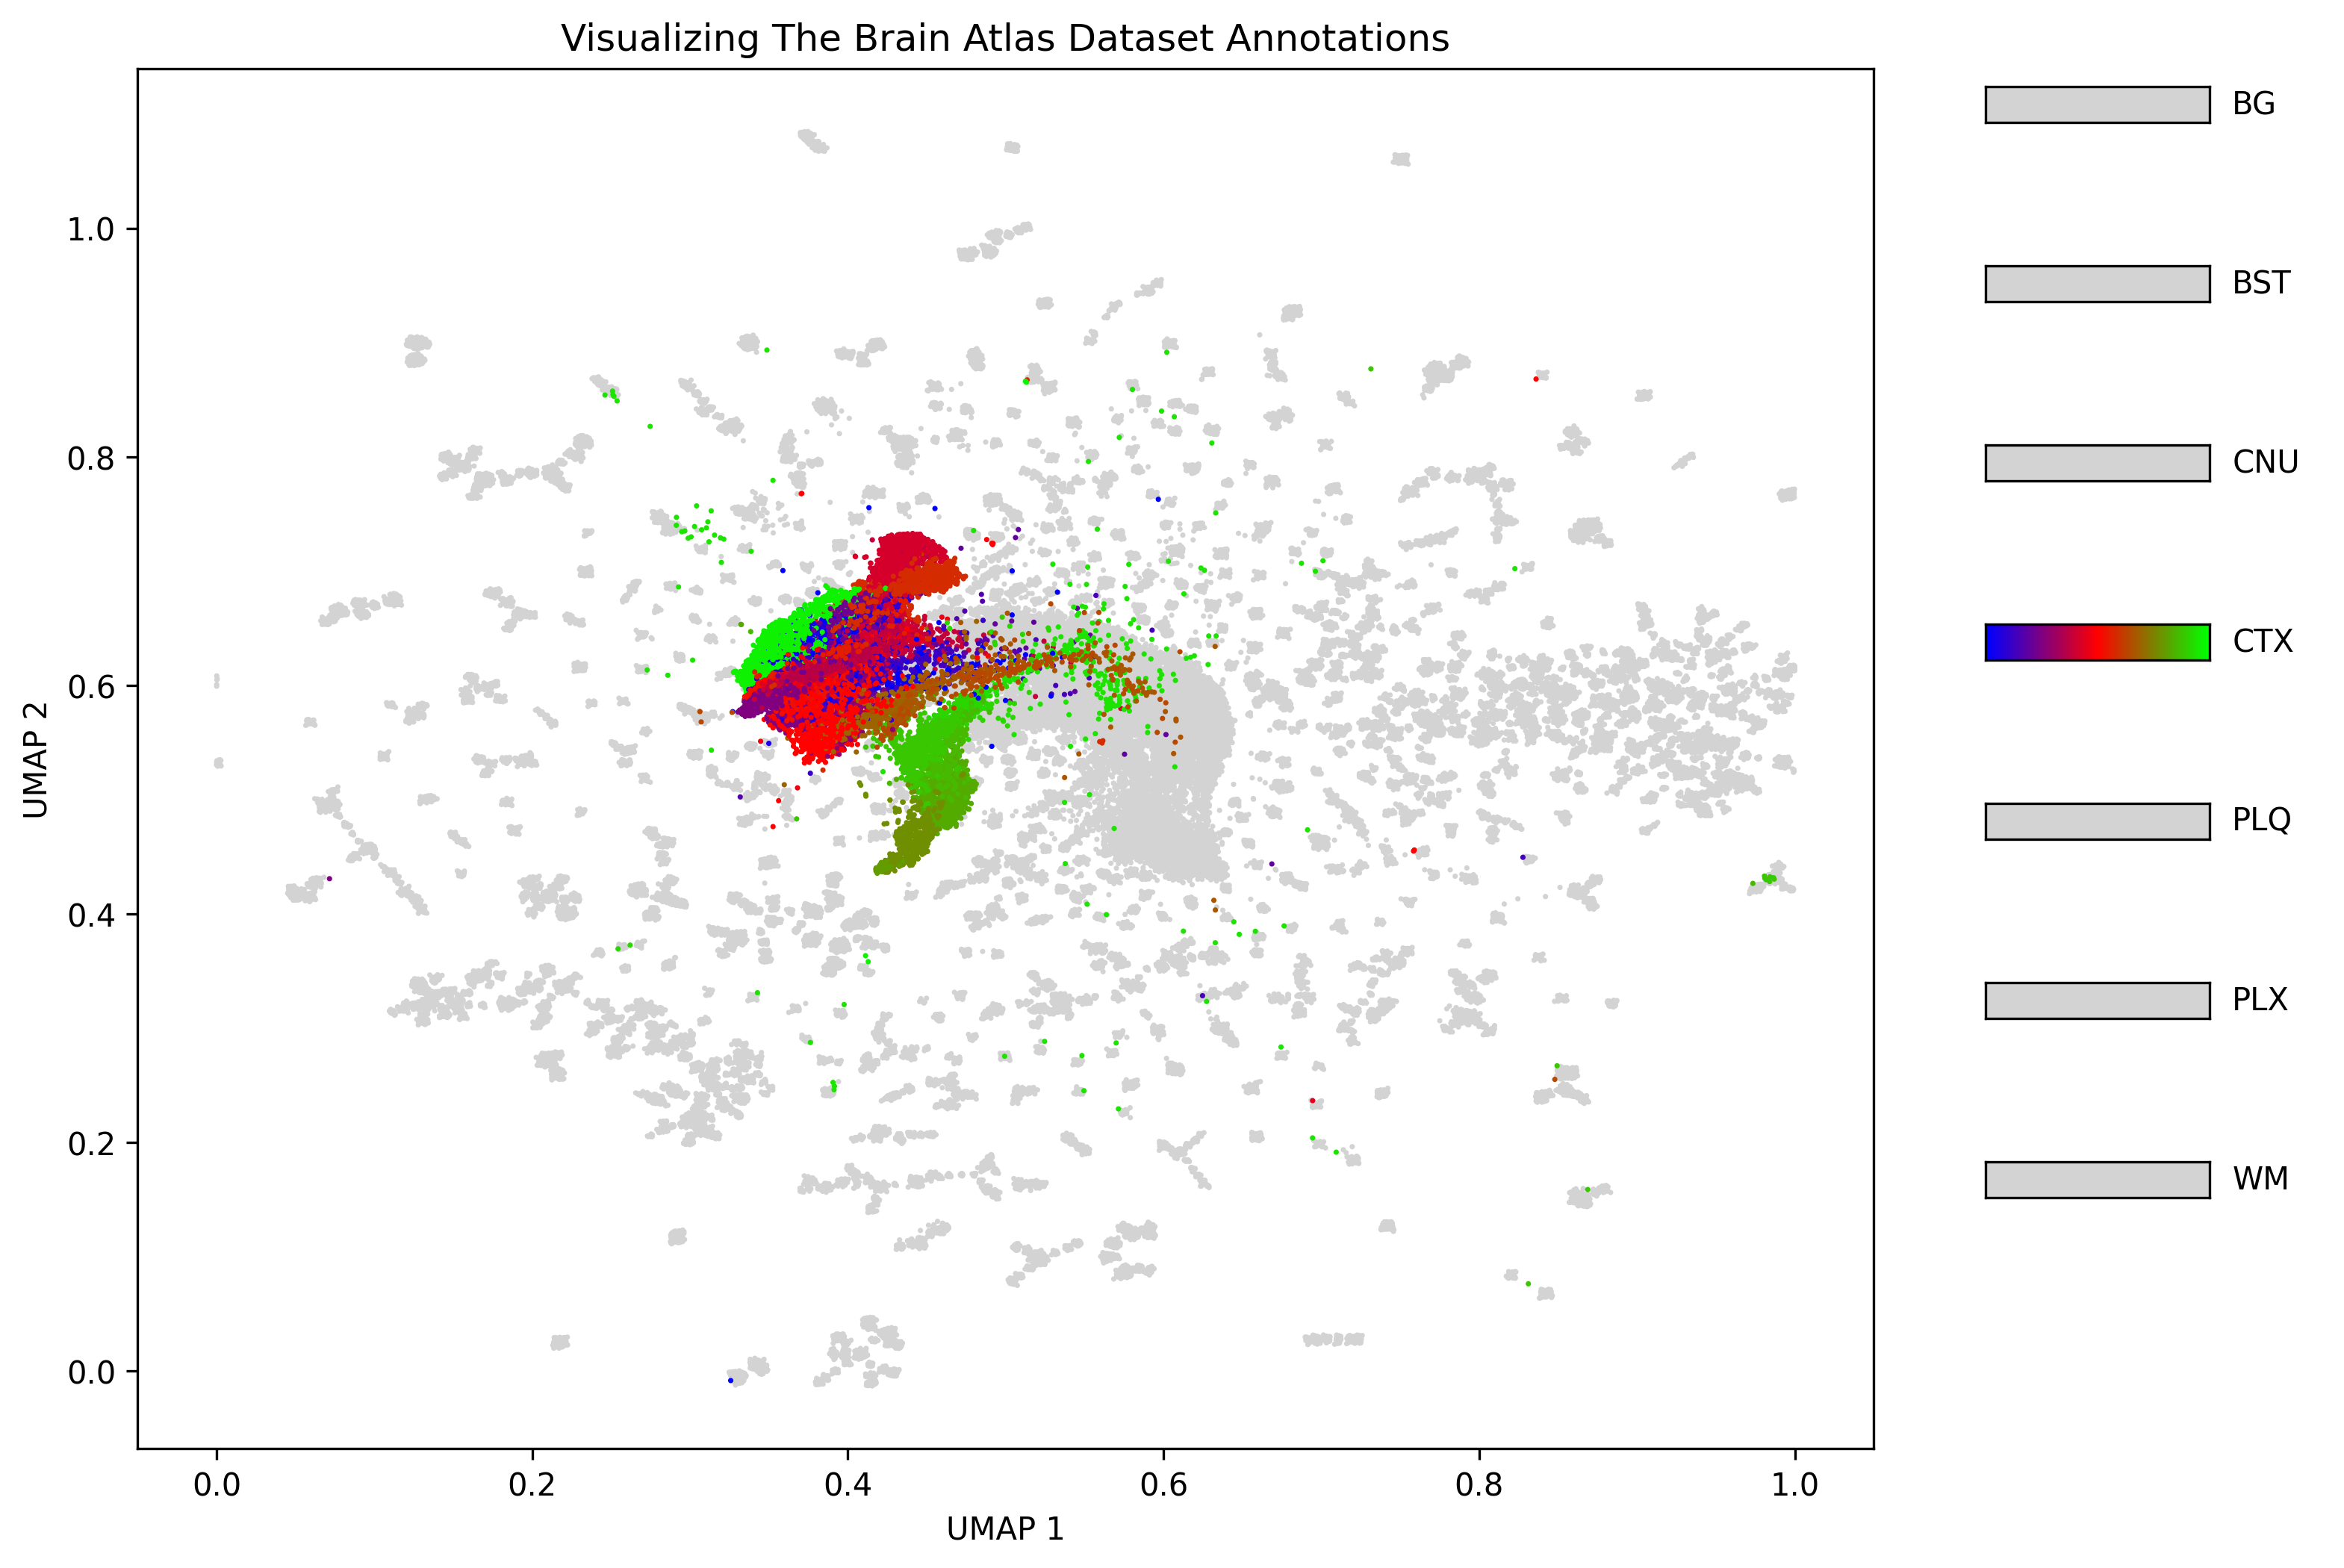

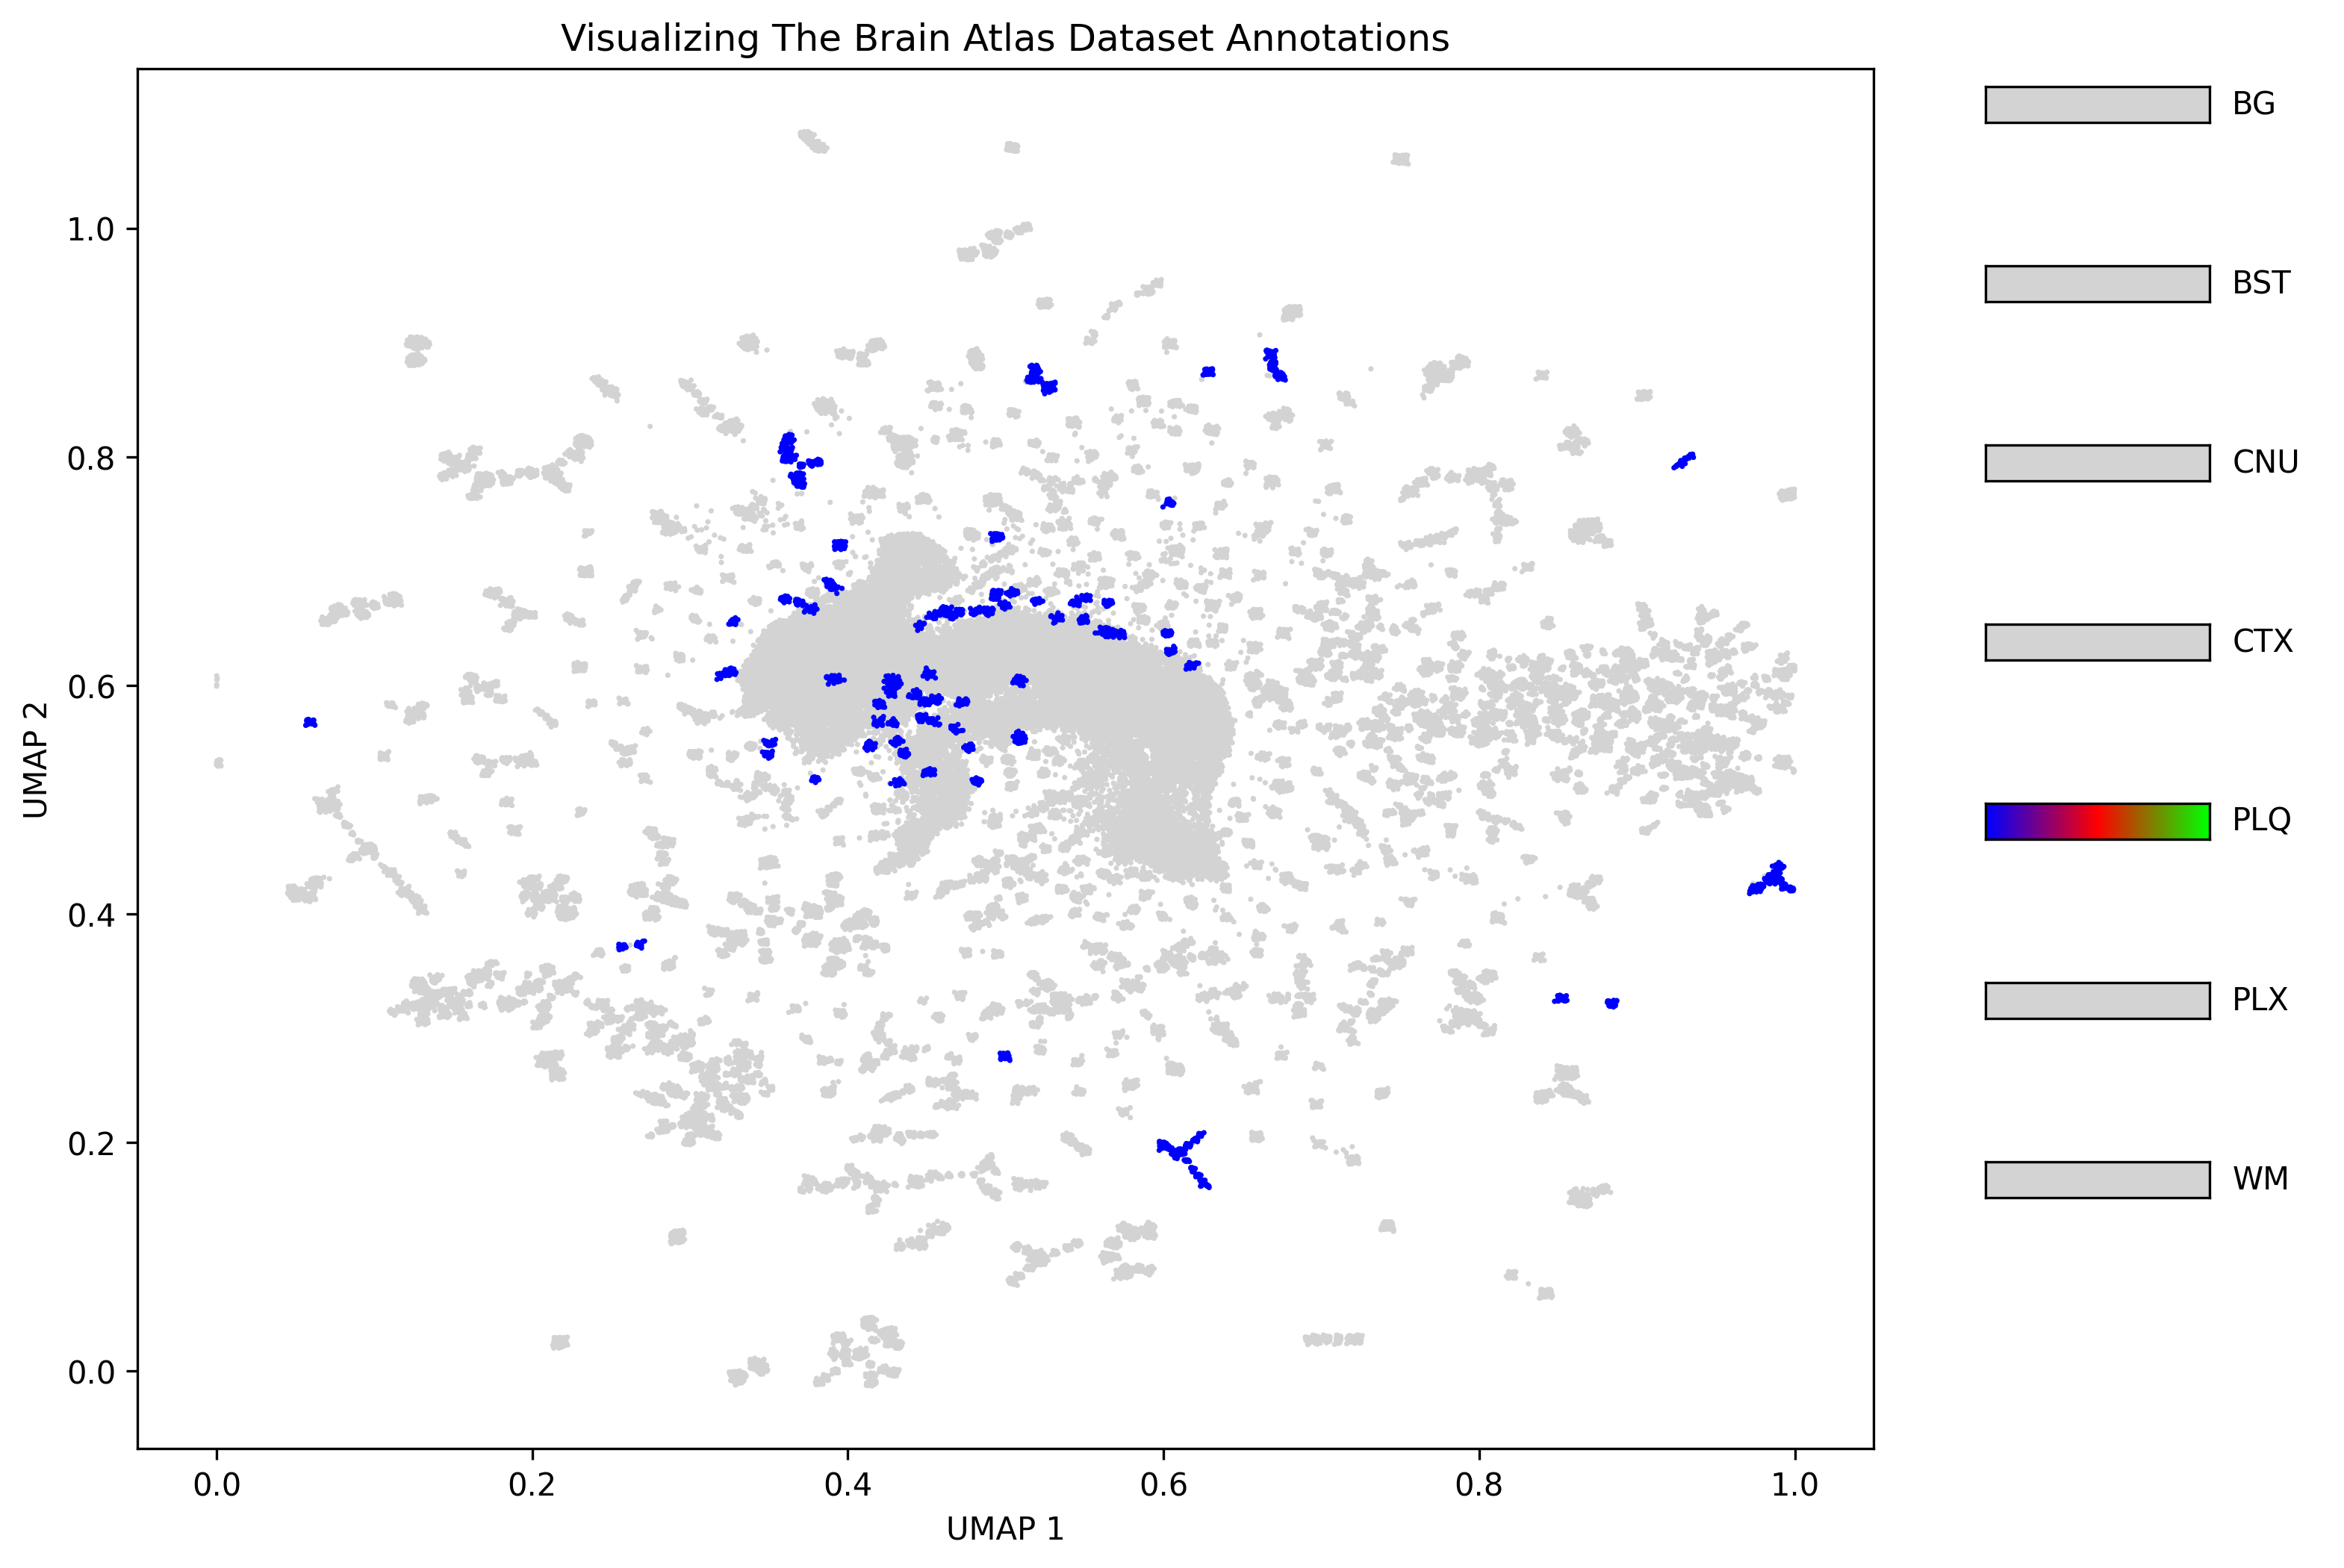

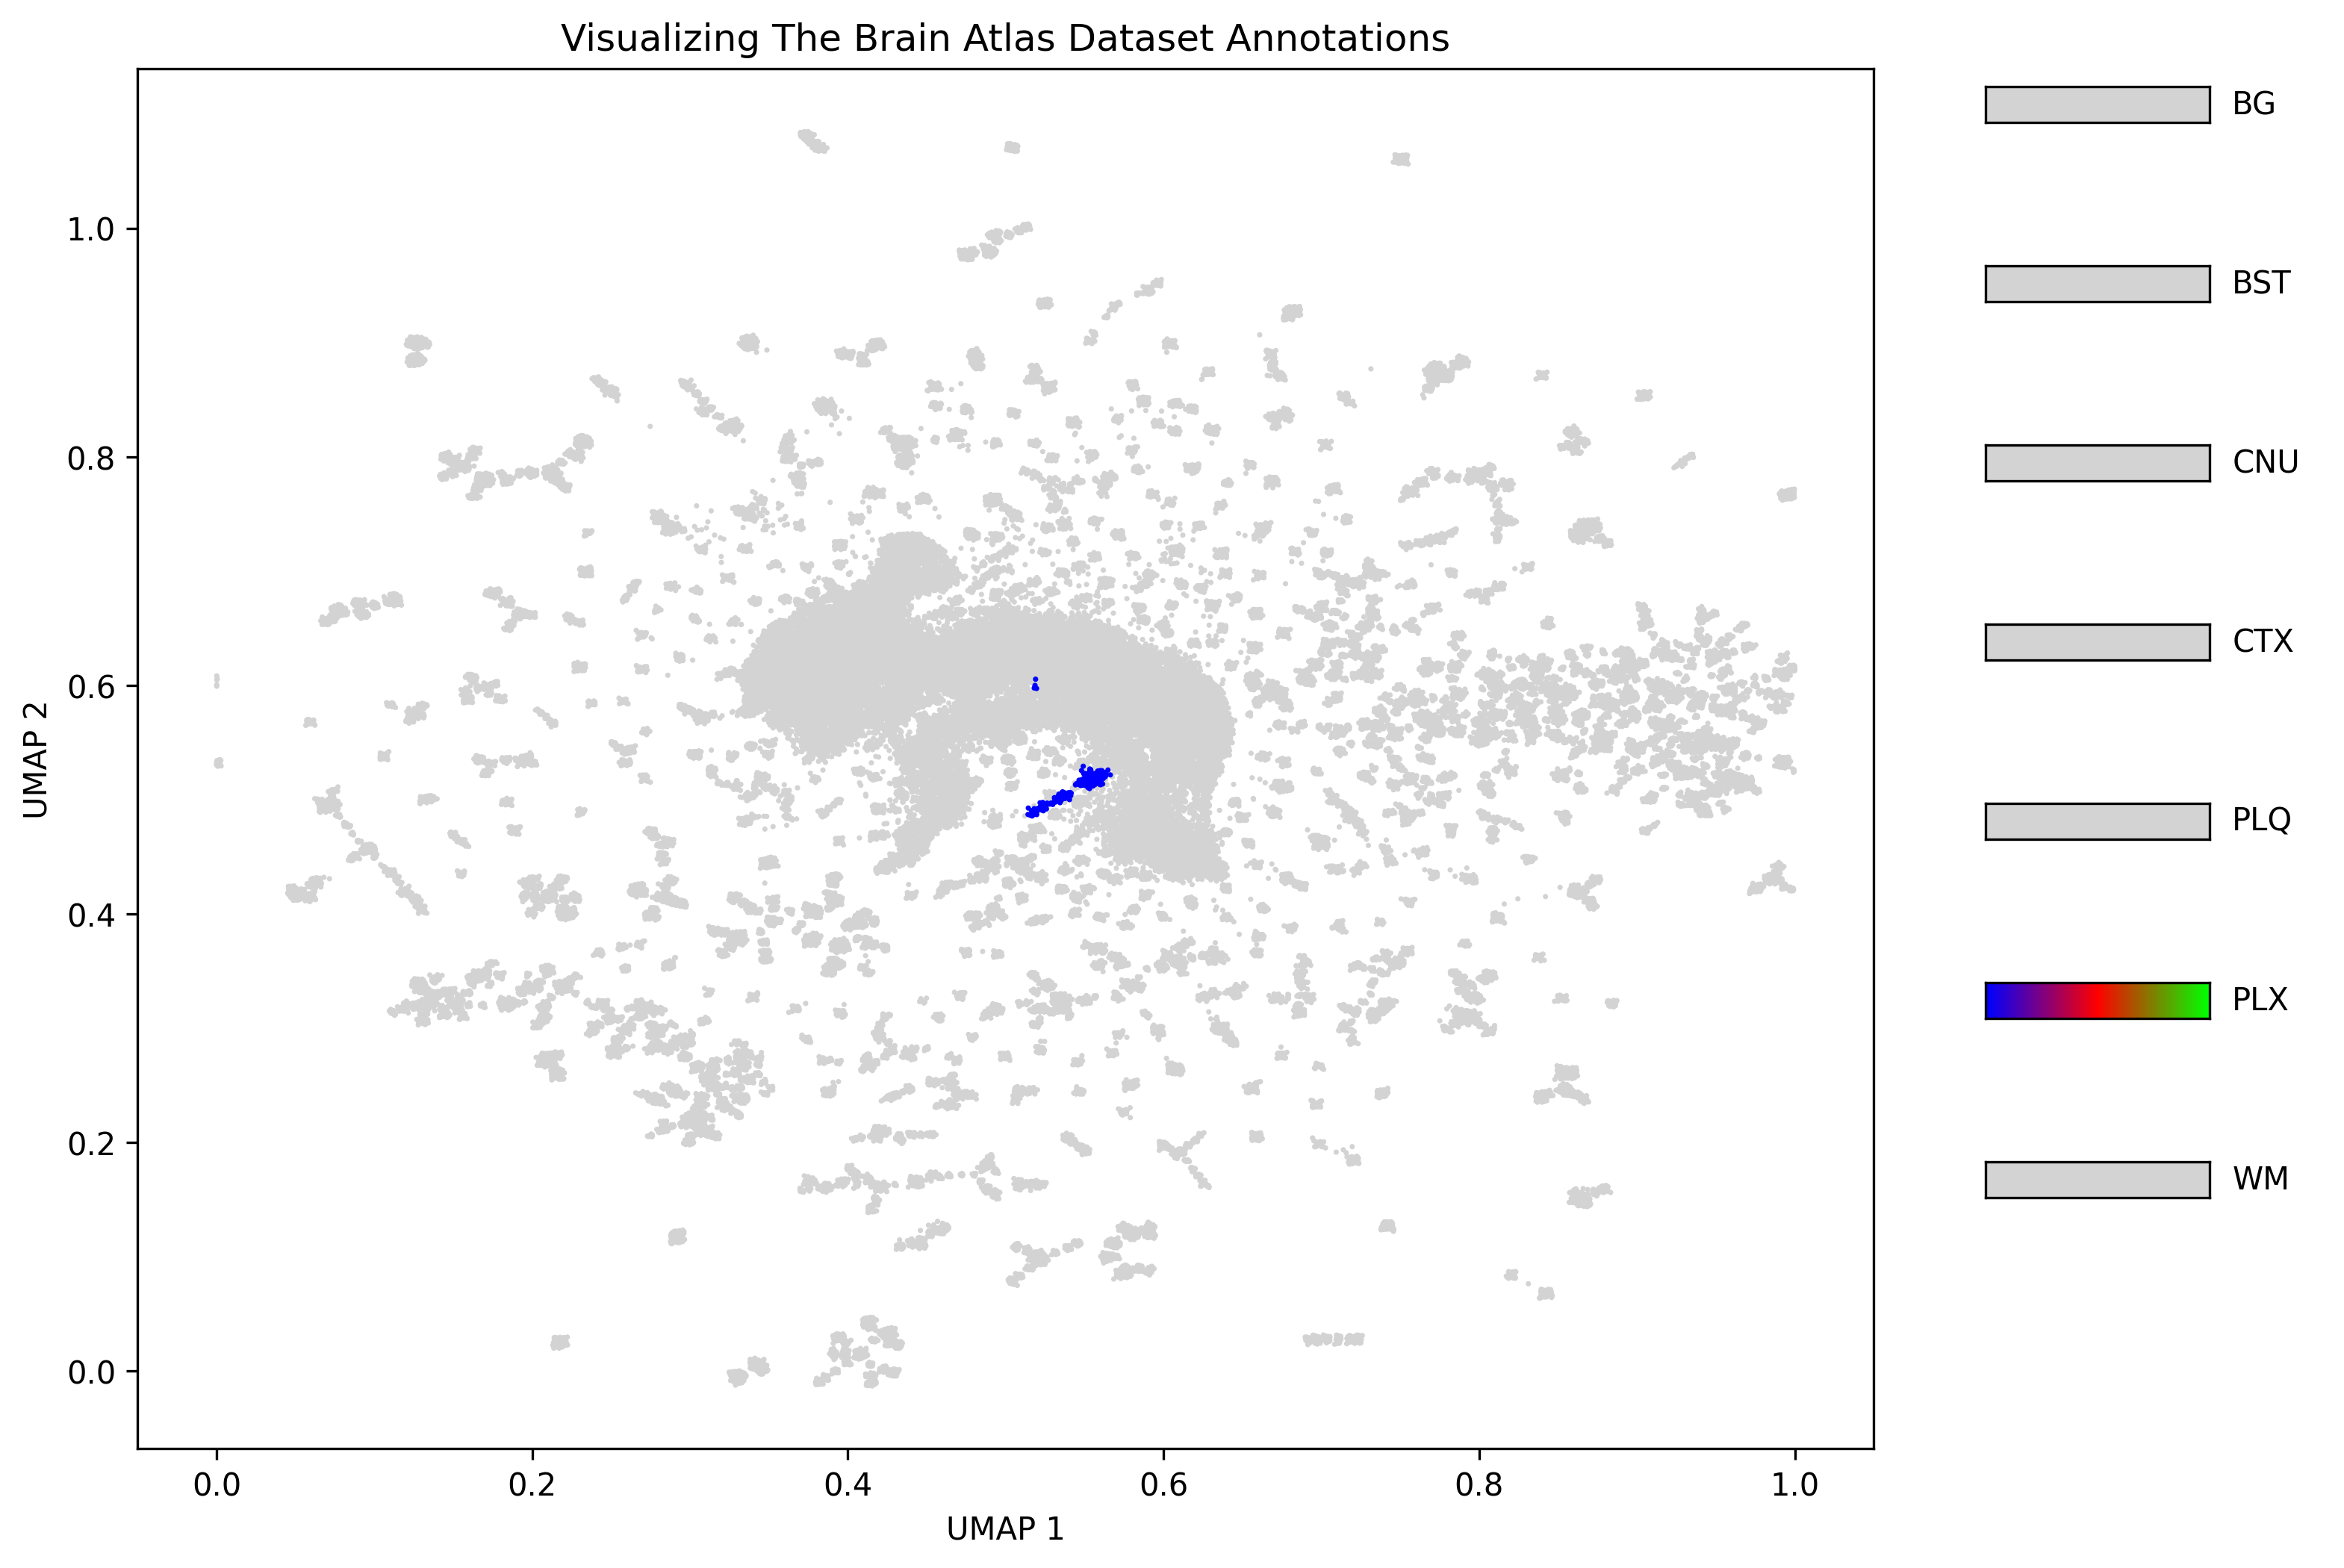

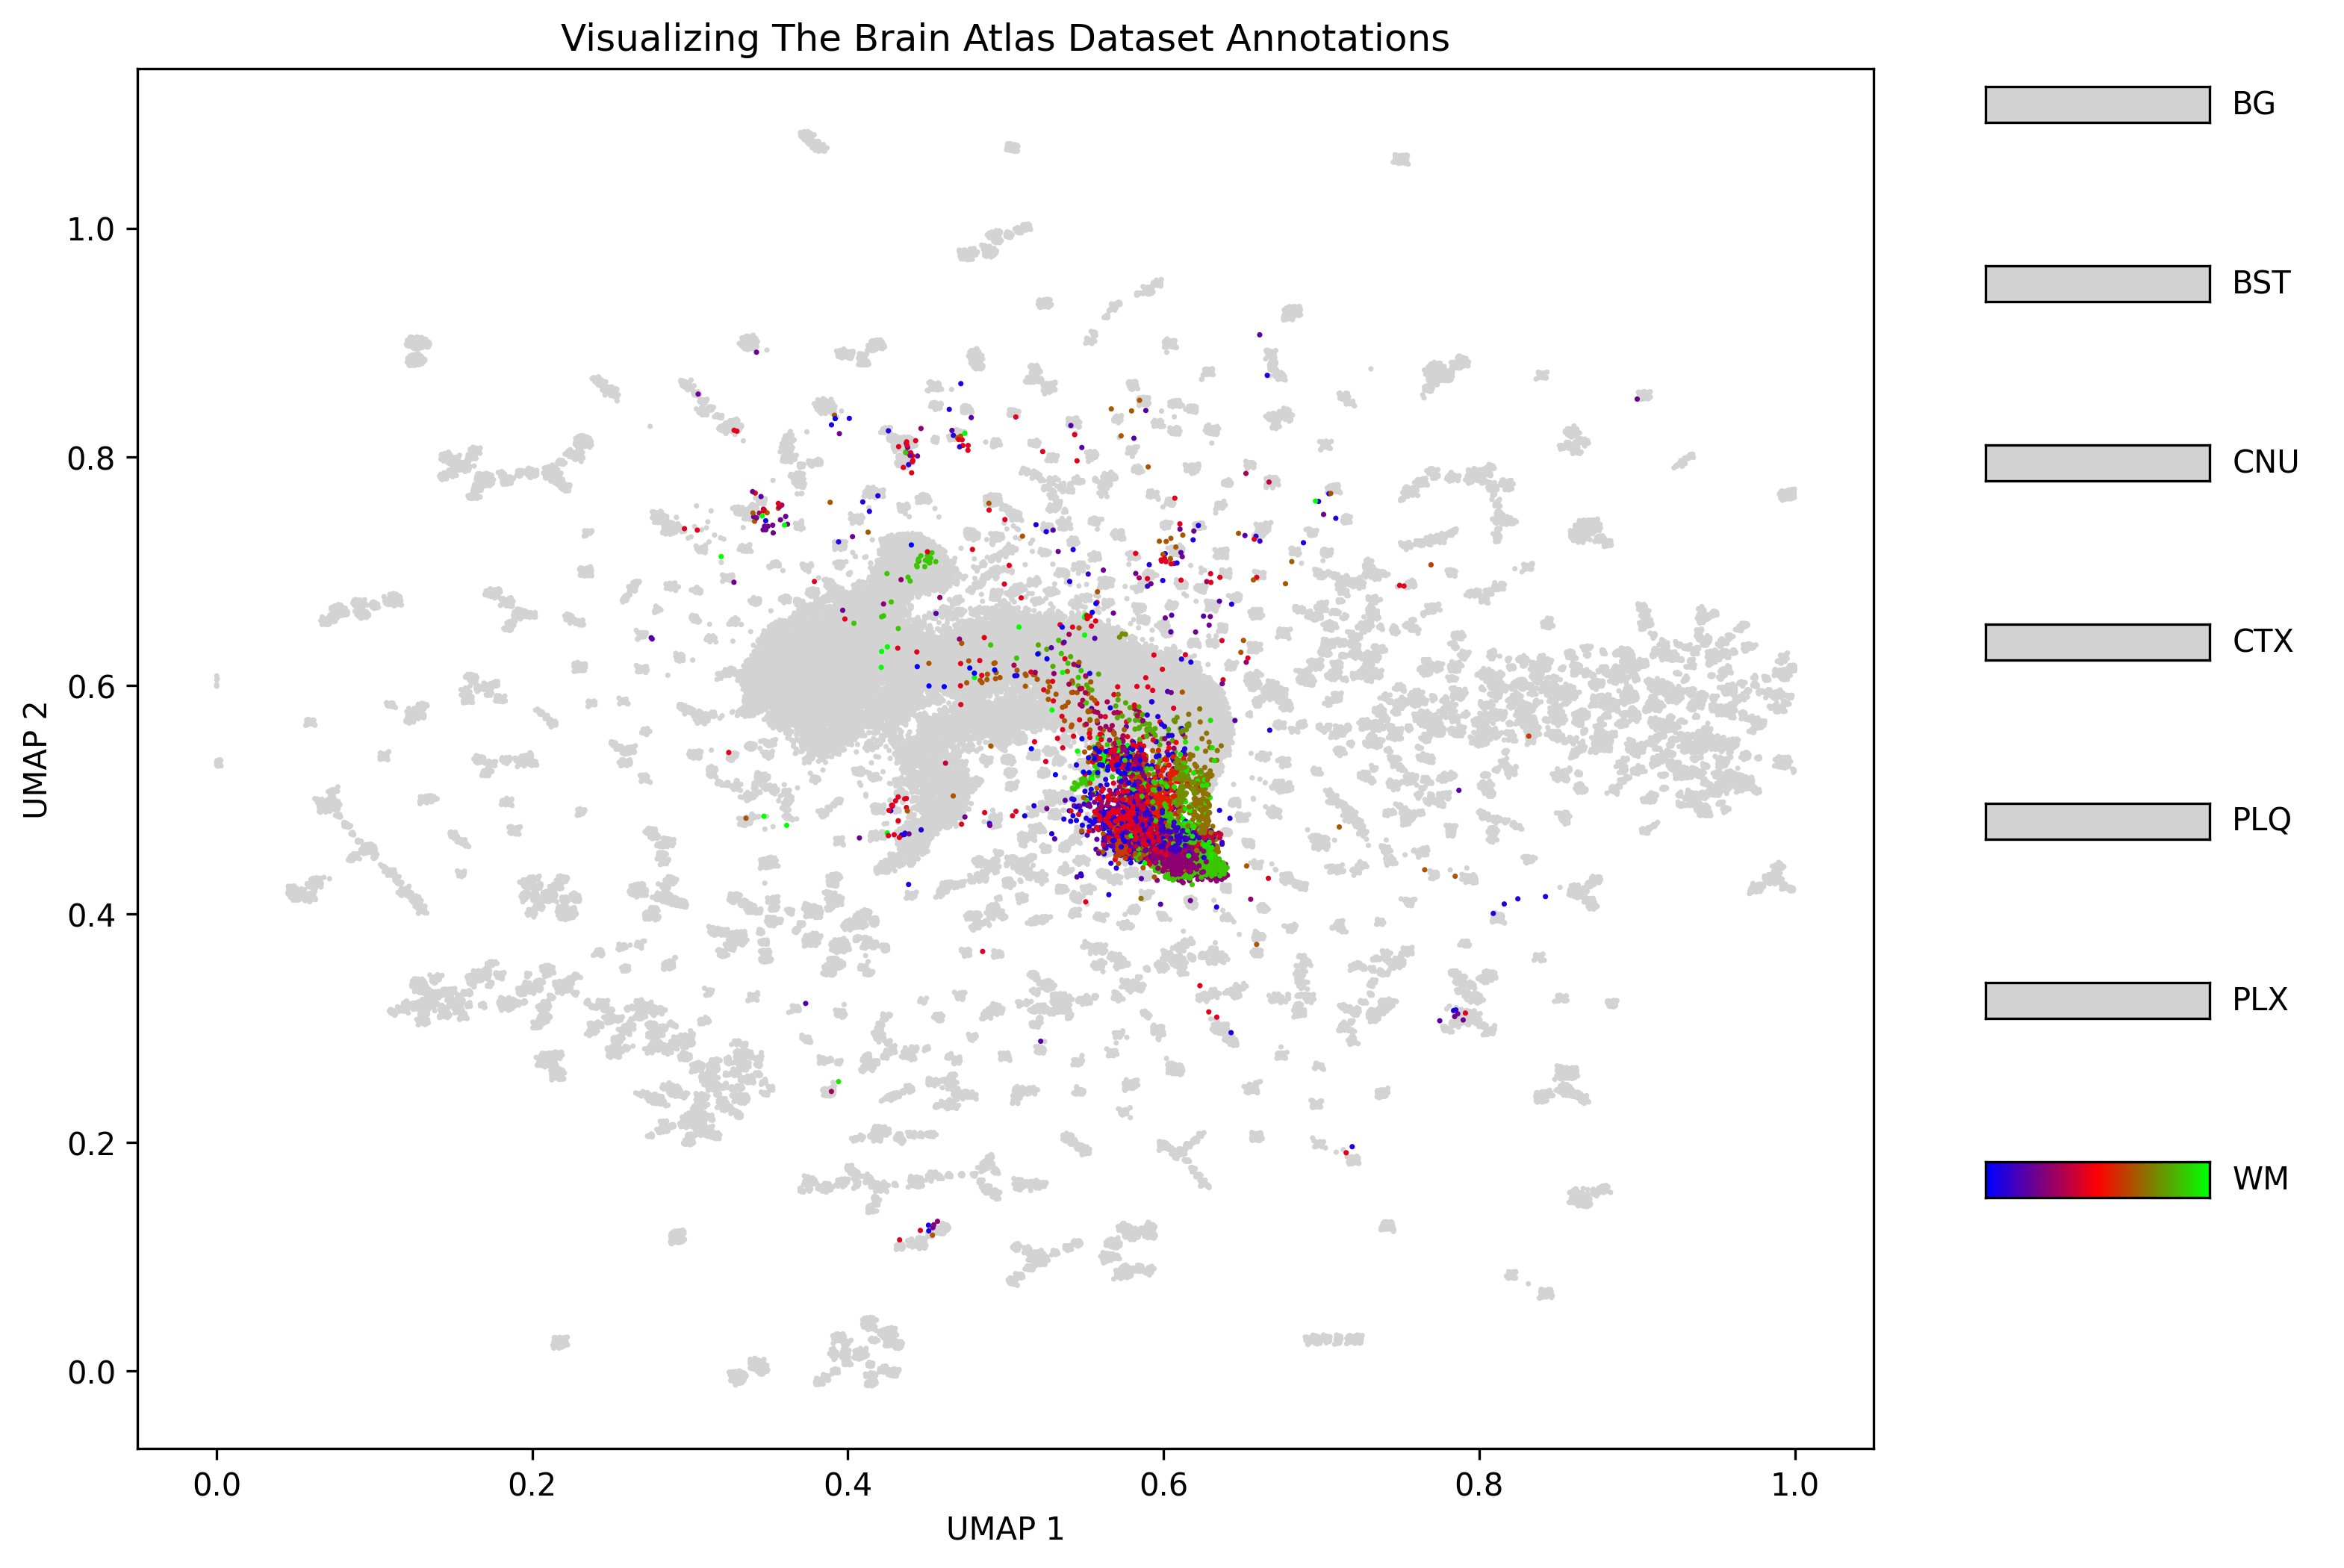

In [2]:
from sklearn.decomposition import PCA
from umap import UMAP
import math
from sklearn.preprocessing import LabelEncoder
import numpy as np
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib.cm import hsv


main_categories = ['BG', 'BST', 'CNU', 'CTX', 'PLQ', 'PLX', 'WM']
colorshemes = ["gist_gray", "bone_r", "Oranges_r", "Greens_r", "Purples_r", "spring", "brg"]

# Create distinct colors for better visualization
colorshemes = [
    "gray",           # BG - gray for background
    "orange",         # BST - orange for brainstem
    "red",           # CNU - red for caudate/putamen
    "green",         # CTX - green for cortex
    "purple",        # PLQ - purple for plaques
    "cyan",          # PLX - cyan for plexus
    "blue"           # WM - blue for white matter
]

# Create a custom colormap from the discrete colors
colors = np.array([plt.cm.colors.to_rgba(c) for c in colorshemes])
custom_cmap = ListedColormap(colors)

orig_colorsmaps = dict(zip(main_categories, colorshemes))
all_y = np.array(all_y)


label_names = all_label_encoder.inverse_transform(all_y)
label_names = [l.split("_")[0] for l in label_names]

label_encoder = LabelEncoder().fit(label_names)
y = label_encoder.transform(label_names)
y = np.array(y)

print(all_y.shape, y.shape)

# Apply PCA to plaque_features
reducer = UMAP(n_components=2, n_neighbors=1000, min_dist=0.9)
features_2d = reducer.fit_transform(X)

# Save UMAP features to disk
np.save('umap_features_2d_20bins.npy', features_2d)

features_2d = np.load("umap_features_2d_20bins.npy")

features_2d_processed = features_2d.copy()
features_2d_processed = features_2d_processed - np.percentile(features_2d_processed, 0.5, axis=0)
features_2d_processed = features_2d_processed / np.percentile((features_2d_processed), 99.5, axis=0)
good_indices = [i for i in range(len(features_2d_processed)) if features_2d_processed[i, 0] > 0 and features_2d_processed[i, 0] < 1]
features_2d_processed = features_2d_processed[good_indices, :]
y_good = y[good_indices]
all_y_good = all_y[good_indices]

y_names = label_encoder.inverse_transform(y_good)
all_y_names = all_label_encoder.inverse_transform(all_y_good)
plt.figure(figsize=(10, 8), dpi=300)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
xx, yy = features_2d_processed[:, 0], features_2d_processed[:, 1]

# Plot each category separately with its own color and label
for i, category in enumerate(label_encoder.classes_):
    mask = y_good == i
    plt.scatter(xx[mask], yy[mask], 
               c=[colors[i]], # Use color from custom colormap
               s=0.5,
               label=category)


# Add legend for each category's colormap
legend_x = 0.95  # Position legend to the right of the plot
legend_y = 0.9   # Start from the top
spacing = 0.05   # Vertical spacing between legend entries
plt.legend(markerscale=10)
# Create a new subplot for the legend
plt.axes([0.9, 0.1, 0.2, 0.8])
plt.axis('off')


for highlight_category in main_categories:
    plt.figure(figsize=(10, 8), dpi=300)
    colorsmaps = {c: LinearSegmentedColormap.from_list("", ["lightgray", "lightgray"])  for c in main_categories}
    colorsmaps[highlight_category] = "brg"
    #colorsmaps = orig_colorsmaps
    parse_categories = [c for c in main_categories if c != highlight_category] + [highlight_category]

    for category in parse_categories:
        indices = [i for i in range(len(y_good)) if category in y_names[i] ]
        ys = y_good[indices]
        all_ys = all_y_good[indices]
        label_names = all_label_encoder.inverse_transform(all_ys)
        l = LabelEncoder().fit(label_names)
        ys_transformed = l.transform(label_names)

        # Create scatter plot
                # scatter = plt.scatter(x, y,
        #                     c=ys_transformed, cmap=colorsmaps[category], s=0.5)

        scatter = plt.scatter(xx[indices], yy[indices], c=ys_transformed, cmap=colorsmaps[category], s=0.5)



    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.title('Visualizing The Brain Atlas Dataset Annotations')


    # Add legend for each category's colormap
    legend_x = 0.95  # Position legend to the right of the plot
    legend_y = 0.9   # Start from the top
    spacing = 0.05   # Vertical spacing between legend entries

    # Create a new subplot for the legend
    plt.axes([0.9, 0.1, 0.2, 0.8])
    plt.axis('off')


    for category in main_categories:
        # Create a gradient array
        gradient = np.linspace(0, 1, 100).reshape(1, -1)
        # Get the colormap
        cmap = plt.get_cmap(colorsmaps[category])
        # Create colored rectangle
        plt.axes([legend_x, legend_y - spacing, 0.1, 0.02])
        plt.imshow(gradient, aspect='auto', cmap=cmap)
        plt.xticks([])
        plt.yticks([])
        # Add category name
        plt.text(1.1, 0.5, category, transform=plt.gca().transAxes,
                verticalalignment='center')
        
        legend_y -= spacing * 2  # Move down for next entry

    #plt.axes([0.1, 0.1, 0.8, 0.8])  # Reset main plotting area
    plt.savefig(f'umap_{category}_20_bins.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.savefig(f'umap_{category}_20_bins.png', dpi=300, bbox_inches='tight')
    #plt.close()